In [6]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [7]:
def read_jsonl(path):
  rows = []
  with open(path, "r", encoding="utf-8") as f:
    for line in f:
      line = line.strip()
      if line:
        rows.append(json.loads(line))
  return rows

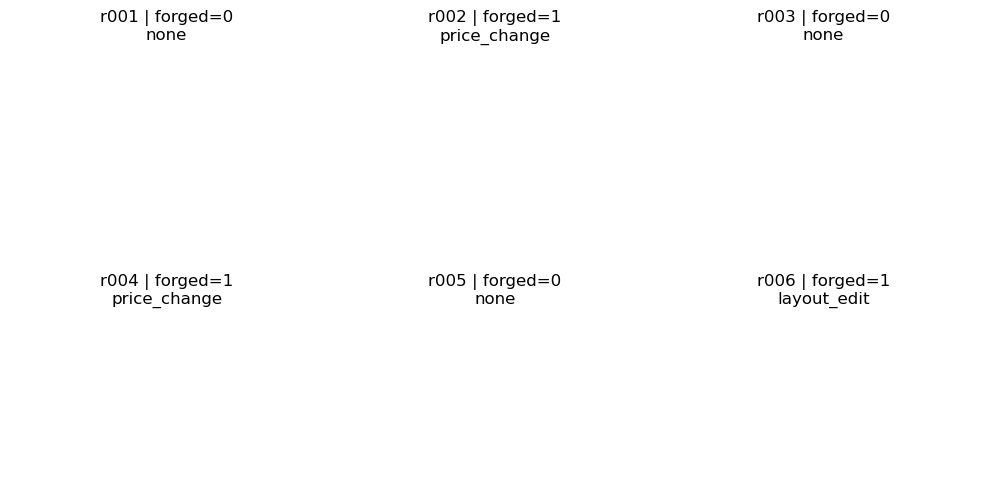

In [ ]:

base = Path(r"C:\ML\dummy_data")
train_dir = base / "train"
train_jsonl = train_dir / "train.jsonl"

records = read_jsonl(train_jsonl)

# Show first 6 samples
n = 6
plt.figure(figsize=(10, 6))

for i in range(min(n, len(records))):
  r = records[i]
  img_path = train_dir / r["image_path"]
  is_forged = r.get("label", {}).get("is_forged", None)
  fraud_type = r.get("label", {}).get("fraud_type", None)

  img = mpimg.imread(img_path)

  ax = plt.subplot(2, 3, i + 1)
  ax.imshow(img)
  ax.axis("off")
  ax.set_title(f'{r["id"]} | forged={is_forged}\n{fraud_type}')

plt.tight_layout()
plt.show()